<div style="color:#3c4d5a; border-top:7px solid #42A5F5; border-bottom:7px solid #42A5F5; padding:8px; text-align:center; text-transform:uppercase">
  <h1>STREAMML - ENTRENAMIENTO Y EVALUACION</h1>
</div>

<strong>Proyecto:</strong> StreamML  | 
  <strong>Integrantes:</strong> Alexis Guaman y Cinthya Ramon  | 
  <strong>Modalidad:</strong> Machine Learning offline

<div id="objetivo" style="color:#106ba3"><h3>Objetivo del notebook</h3> </div>

Este notebook entrena y evalua dos clasificadores con responsabilidades diferentes. El reactivo recomienda un perfil de calidad a partir de condiciones actuales; el predictivo estima si la capacidad observada permite mantener el perfil durante el horizonte definido en su contrato.

El resultado esperado es una comparacion reproducible de algoritmos y baselines, una seleccion basada unicamente en validacion y una evaluacion final honesta sobre test. Los modelos, contratos, metricas y manifiestos se publican juntos para que las cifras mostradas puedan verificarse posteriormente.

<div id="requisitos" style="color:#106ba3"><h3>Requisitos, entradas y salida esperada</h3> </div>

Se utiliza Python 3.11 con scikit-learn, pandas, NumPy, joblib y Matplotlib, instalados mediante `pip install -r requirements.txt`. Las entradas son los datasets finales de `data/processed/` y los contratos de `config/` producidos y auditados en el notebook anterior.

El entrenamiento se delega a scripts oficiales para mantener una sola implementacion. Se espera obtener comparaciones contra baseline, seleccion con validacion, evaluacion final sobre test y artefactos autocontenidos en `models/release/`.

El test se reserva como estimacion final de generalizacion. No se utiliza para escoger algoritmo, hiperparametros o threshold, incluso si otra configuracion pareciera mejorar sus resultados.

<div id="contenido" style="color:#106ba3"><h3>Contenido</h3> </div>

- [Objetivo](#objetivo)
- [Fundamentos metodologicos](#fundamentos-metodologicos)
- [Fase 1: Entorno y datasets preparados](#fase-1-entorno-y-datasets-preparados)
- [Fase 2: Entrenamiento reproducible](#fase-2-entrenamiento-reproducible)
- [Fase 3: Baselines y comparacion de algoritmos](#fase-3-baselines-y-comparacion-de-algoritmos)
- [Fase 4: Seleccion y threshold predictivo](#fase-4-seleccion-y-threshold-predictivo)
- [Fase 5: Metricas de validacion y test](#fase-5-metricas-de-validacion-y-test)
- [Fase 6: Matrices de confusion](#fase-6-matrices-de-confusion)
- [Fase 7: Importancia de variables](#fase-7-importancia-de-variables)
- [Fase 8: Artefactos oficiales](#fase-8-artefactos-oficiales)
- [Conclusiones](#conclusiones)
- [Referencias](#referencias)

<div id="fundamentos-metodologicos" style="color:#37475a; border-bottom: 7px solid orange; width: 100%; margin-bottom: 15px; padding-bottom: 2px"><h2>Fundamentos metodologicos</h2> </div>

Un modelo debe compararse con una estrategia simple para demostrar que aprende algo util. El baseline de clase mayoritaria representa la decision que se obtendria ignorando todas las variables. Superarlo en accuracy no basta cuando las clases estan desbalanceadas, porque predecir siempre la categoria dominante puede parecer exitoso.

Por esa razon la seleccion prioriza Macro F1, que asigna igual importancia a cada clase, y balanced accuracy, que promedia su recall. La busqueda de hiperparametros se limita al entrenamiento y la eleccion final utiliza validacion. Test se consulta una sola vez como evidencia de generalizacion.

<div id="fase-1-entorno-y-datasets-preparados" style="color:#37475a; border-bottom: 7px solid orange; width: 100%; margin-bottom: 15px; padding-bottom: 2px"><h2>Fase 1: Entorno y datasets preparados</h2> </div>

Se cargan los CSV producidos por el notebook de preparacion y los dos contratos de variables. Antes de entrenar se verifica que las columnas requeridas y los targets existen. Esto evita que scikit-learn reciba un dataframe incompleto o que una columna cambie de nombre sin ser detectada.

La tabla inicial comunica el volumen y la dimensionalidad de cada problema. El reactivo utiliza tres mediciones actuales; el predictivo utiliza 19 estadisticas historicas. Son espacios de entrada distintos y, por tanto, se entrenan y publican como modelos independientes.

In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", lambda value: f"{value:.4f}")
print("Proyecto:", ROOT.name)

import subprocess
import joblib

reactive = pd.read_csv(ROOT / "data" / "processed" / "reactive_dataset.csv")
predictive = pd.read_csv(ROOT / "data" / "processed" / "predictive_dataset.csv")
reactive_contract = json.loads((ROOT / "config" / "reactive_feature_contract.json").read_text(encoding="utf-8"))
predictive_contract = json.loads((ROOT / "config" / "predictive_feature_contract.json").read_text(encoding="utf-8"))
assert set(reactive_contract["features"] + ["target"]).issubset(reactive.columns)
assert set(predictive_contract["features"] + ["target_code"]).issubset(predictive.columns)
display(pd.DataFrame({"dataset": ["reactive", "predictive"], "rows": [len(reactive), len(predictive)], "features": [3, 19]}))

Proyecto: Adaptive-Streaming-ai


,dataset,rows,features
0,reactive,26686,3
1,predictive,3306,19


<div id="fase-2-entrenamiento-reproducible" style="color:#37475a; border-bottom: 7px solid orange; width: 100%; margin-bottom: 15px; padding-bottom: 2px"><h2>Fase 2: Entrenamiento reproducible</h2> </div>

El notebook delega el entrenamiento a `scripts/train_models.py` y la evaluacion a `scripts/evaluate_models.py`. Esta decision evita duplicar logica entre celdas y scripts: el mismo codigo que se usa en una ejecucion automatizada es el que genera los resultados mostrados aqui.

Se comparan baseline, regresion logistica, arbol de decision y random forest. La busqueda interna respeta grupos de sesiones. Despues de seleccionar con validacion, el estimador elegido se ajusta con los datos permitidos y se evalua sobre las sesiones reservadas de test.

In [2]:
def run_script(name):
    completed = subprocess.run(
        [sys.executable, str(ROOT / "scripts" / name)],
        cwd=ROOT,
        check=True,
        capture_output=True,
        text=True,
    )
    print(f"{name}: OK")
    return completed.stdout

run_script("train_models.py")
run_script("evaluate_models.py")

train_models.py: OK


evaluate_models.py: OK


'{\n  "reactive_test_macro_f1": 0.9990675504447246,\n  "predictive_test_macro_f1": 0.9324896313574548,\n  "predictive_threshold": 0.5\n}\n'

<div id="fase-3-baselines-y-comparacion-de-algoritmos" style="color:#37475a; border-bottom: 7px solid orange; width: 100%; margin-bottom: 15px; padding-bottom: 2px"><h2>Fase 3: Baselines y comparacion de algoritmos</h2> </div>

Las tablas de comparacion se reconstruyen desde `metrics.json`, generado en la celda anterior. Para cada algoritmo se muestran rendimiento de validacion y, cuando corresponde, la puntuacion obtenida mediante validacion cruzada agrupada dentro de train.

El baseline establece el minimo operativo. Una diferencia amplia de Macro F1 indica que el modelo reconoce ambas clases mejor que una politica constante. Sin embargo, la comparacion de candidatos se hace con validacion; las metricas de test no aparecen como criterio de ordenamiento.

In [3]:
release_dir = ROOT / "models" / "release"
reactive_metrics = json.loads((release_dir / "reactive" / "metrics.json").read_text(encoding="utf-8"))
predictive_metrics = json.loads((release_dir / "predictive" / "metrics.json").read_text(encoding="utf-8"))

def comparison_table(metrics):
    rows = []
    for name, result in metrics["model_comparison"].items():
        rows.append({
            "model": name,
            "train_groupkfold_macro_f1": result["train_groupkfold_macro_f1"],
            "validation_macro_f1": result["validation"]["macro_f1"],
            "validation_balanced_accuracy": result["validation"]["balanced_accuracy"],
        })
    return pd.DataFrame(rows).sort_values(["validation_macro_f1", "validation_balanced_accuracy"], ascending=False)

display(comparison_table(reactive_metrics))
display(comparison_table(predictive_metrics))
display(pd.DataFrame([
    {"role": "reactive", "baseline_test_macro_f1": reactive_metrics["baseline"]["test"]["macro_f1"]},
    {"role": "predictive", "baseline_test_macro_f1": predictive_metrics["baseline"]["test"]["macro_f1"]},
]))

,model,train_groupkfold_macro_f1,validation_macro_f1,validation_balanced_accuracy
2,DecisionTreeClassifier,0.9995,1.0000,1.0000
3,RandomForestClassifier,0.9984,0.9993,0.9994
1,LogisticRegression,0.8240,0.8286,0.9293
0,DummyClassifier,NaN,0.3015,0.3333


,model,train_groupkfold_macro_f1,validation_macro_f1,validation_balanced_accuracy
3,RandomForestClassifier,0.9828,0.9906,0.9973
2,DecisionTreeClassifier,0.9763,0.9785,0.9937
1,LogisticRegression,0.9828,0.9697,0.9909
0,DummyClassifier,NaN,0.4615,0.5000


,role,baseline_test_macro_f1
0,reactive,0.3017
1,predictive,0.4799


<div id="fase-4-seleccion-y-threshold-predictivo" style="color:#37475a; border-bottom: 7px solid orange; width: 100%; margin-bottom: 15px; padding-bottom: 2px"><h2>Fase 4: Seleccion y threshold predictivo</h2> </div>

El modelo reactivo produce directamente una clase entre tres opciones. El predictivo produce una probabilidad para `downgrade_needed`, por lo que necesita un threshold para convertirla en decision. Distintos valores cambian el equilibrio entre alarmas preventivas y degradaciones no detectadas.

El threshold se explora exclusivamente con validacion y se persiste junto al modelo. La tabla permite observar su efecto sobre Macro F1, balanced accuracy y recall. Test no se utiliza para reajustarlo despues de conocer los errores finales.

In [4]:
selection = pd.DataFrame([
    {"role": "reactive", "selected_model": reactive_metrics["selected_model"], "threshold": np.nan, "validation_macro_f1": reactive_metrics["validation"]["macro_f1"], "validation_balanced_accuracy": reactive_metrics["validation"]["balanced_accuracy"]},
    {"role": "predictive", "selected_model": predictive_metrics["selected_model"], "threshold": predictive_metrics["threshold"], "validation_macro_f1": predictive_metrics["validation"]["macro_f1"], "validation_balanced_accuracy": predictive_metrics["validation"]["balanced_accuracy"]},
])
display(selection)

threshold_search = predictive_metrics["model_comparison"][predictive_metrics["selected_model"]]["threshold_search"]
display(pd.DataFrame(threshold_search).sort_values("threshold"))

,role,selected_model,threshold,validation_macro_f1,validation_balanced_accuracy
0,reactive,DecisionTreeClassifier,NaN,1.0000,1.0000
1,predictive,RandomForestClassifier,0.5000,0.9906,0.9973


,accuracy,balanced_accuracy,precision_by_class,recall_by_class,f1_by_class,support_by_class,macro_f1,recall_downgrade_needed,pr_auc,roc_auc,confusion_matrix,false_positives,false_negatives,threshold
0,0.9953,0.9973,"{'maintain': 0.968421052631579, 'downgrade_nee...","{'maintain': 1.0, 'downgrade_needed': 0.994565...","{'maintain': 0.983957219251337, 'downgrade_nee...","{'maintain': 92, 'downgrade_needed': 552}",0.9906,0.9946,1.0000,1.0000,"[[92, 0], [3, 549]]",0,3,0.3000
1,0.9953,0.9973,"{'maintain': 0.968421052631579, 'downgrade_nee...","{'maintain': 1.0, 'downgrade_needed': 0.994565...","{'maintain': 0.983957219251337, 'downgrade_nee...","{'maintain': 92, 'downgrade_needed': 552}",0.9906,0.9946,1.0000,1.0000,"[[92, 0], [3, 549]]",0,3,0.3500
2,0.9953,0.9973,"{'maintain': 0.968421052631579, 'downgrade_nee...","{'maintain': 1.0, 'downgrade_needed': 0.994565...","{'maintain': 0.983957219251337, 'downgrade_nee...","{'maintain': 92, 'downgrade_needed': 552}",0.9906,0.9946,1.0000,1.0000,"[[92, 0], [3, 549]]",0,3,0.4000
3,0.9953,0.9973,"{'maintain': 0.968421052631579, 'downgrade_nee...","{'maintain': 1.0, 'downgrade_needed': 0.994565...","{'maintain': 0.983957219251337, 'downgrade_nee...","{'maintain': 92, 'downgrade_needed': 552}",0.9906,0.9946,1.0000,1.0000,"[[92, 0], [3, 549]]",0,3,0.4500
4,0.9953,0.9973,"{'maintain': 0.968421052631579, 'downgrade_nee...","{'maintain': 1.0, 'downgrade_needed': 0.994565...","{'maintain': 0.983957219251337, 'downgrade_nee...","{'maintain': 92, 'downgrade_needed': 552}",0.9906,0.9946,1.0000,1.0000,"[[92, 0], [3, 549]]",0,3,0.5000
5,0.9938,0.9964,"{'maintain': 0.9583333333333334, 'downgrade_ne...","{'maintain': 1.0, 'downgrade_needed': 0.992753...","{'maintain': 0.9787234042553191, 'downgrade_ne...","{'maintain': 92, 'downgrade_needed': 552}",0.9875,0.9928,1.0000,1.0000,"[[92, 0], [4, 548]]",0,4,0.5500
6,0.9938,0.9964,"{'maintain': 0.9583333333333334, 'downgrade_ne...","{'maintain': 1.0, 'downgrade_needed': 0.992753...","{'maintain': 0.9787234042553191, 'downgrade_ne...","{'maintain': 92, 'downgrade_needed': 552}",0.9875,0.9928,1.0000,1.0000,"[[92, 0], [4, 548]]",0,4,0.6000
7,0.9938,0.9964,"{'maintain': 0.9583333333333334, 'downgrade_ne...","{'maintain': 1.0, 'downgrade_needed': 0.992753...","{'maintain': 0.9787234042553191, 'downgrade_ne...","{'maintain': 92, 'downgrade_needed': 552}",0.9875,0.9928,1.0000,1.0000,"[[92, 0], [4, 548]]",0,4,0.6500


<div id="fase-5-metricas-de-validacion-y-test" style="color:#37475a; border-bottom: 7px solid orange; width: 100%; margin-bottom: 15px; padding-bottom: 2px"><h2>Fase 5: Metricas de validacion y test</h2> </div>

Se presentan accuracy, balanced accuracy y Macro F1 para obtener perspectivas complementarias. Accuracy mide la proporcion total de aciertos; balanced accuracy evita que la clase dominante oculte fallos; Macro F1 combina precision y recall dando el mismo peso a cada categoria.

El recall y F1 por clase permiten comprobar que ninguna categoria fue ignorada. La separacion entre validacion y test ayuda a detectar una brecha de generalizacion: una caida en test no invalida automaticamente el modelo, pero indica cuanta cautela requiere aplicarlo fuera de las sesiones observadas.

In [5]:
def metrics_table(role, metrics):
    rows = []
    for split in ["validation", "test"]:
        result = metrics[split]
        row = {
            "role": role,
            "split": split,
            "accuracy": result["accuracy"],
            "balanced_accuracy": result["balanced_accuracy"],
            "macro_f1": result["macro_f1"],
        }
        for label, value in result["recall_by_class"].items():
            row[f"recall_{label}"] = value
        for label, value in result["f1_by_class"].items():
            row[f"f1_{label}"] = value
        rows.append(row)
    return rows

metrics_summary = pd.DataFrame(metrics_table("reactive", reactive_metrics) + metrics_table("predictive", predictive_metrics))
display(metrics_summary)

,role,split,accuracy,balanced_accuracy,macro_f1,recall_low,recall_medium,recall_high,f1_low,f1_medium,f1_high,recall_maintain,recall_downgrade_needed,f1_maintain,f1_downgrade_needed
0,reactive,validation,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,NaN,NaN,NaN,NaN
1,reactive,test,0.9996,0.9983,0.9991,1.0000,0.9949,1.0000,1.0000,0.9974,0.9998,NaN,NaN,NaN,NaN
2,predictive,validation,0.9953,0.9973,0.9906,NaN,NaN,NaN,NaN,NaN,NaN,1.0000,0.9946,0.9840,0.9973
3,predictive,test,0.9797,0.9568,0.9325,NaN,NaN,NaN,NaN,NaN,NaN,0.9298,0.9839,0.8760,0.9889


<div id="fase-6-matrices-de-confusion" style="color:#37475a; border-bottom: 7px solid orange; width: 100%; margin-bottom: 15px; padding-bottom: 2px"><h2>Fase 6: Matrices de confusion</h2> </div>

La matriz de confusion ubica las clases reales en filas y las predicciones en columnas. La diagonal contiene aciertos; los valores fuera de ella muestran exactamente que clases se confunden. Esto permite interpretar errores que una metrica agregada resume en un solo numero.

En el modelo predictivo, un falso negativo representa una ventana que requeria reducir calidad pero fue clasificada como mantenimiento. Un falso positivo recomienda reducir cuando el perfil podia mantenerse. Ambos errores tienen costos diferentes y deben considerarse al diseñar una politica futura.

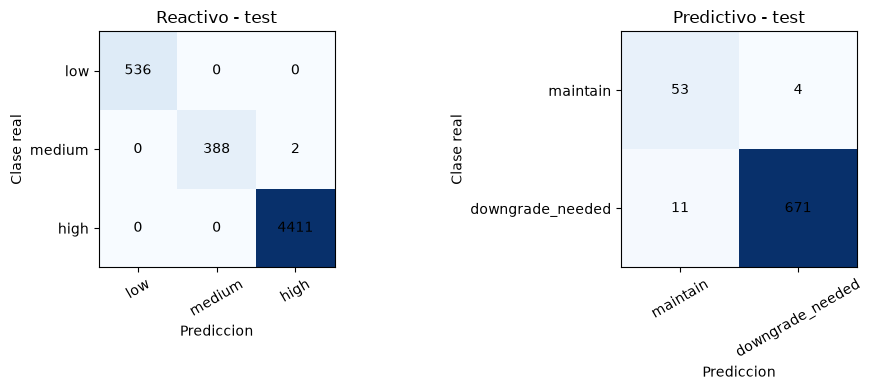

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, title, result, labels in [
    (axes[0], "Reactivo - test", reactive_metrics["test"], ["low", "medium", "high"]),
    (axes[1], "Predictivo - test", predictive_metrics["test"], ["maintain", "downgrade_needed"]),
]:
    matrix = np.asarray(result["confusion_matrix"])
    image = ax.imshow(matrix, cmap="Blues")
    for row in range(matrix.shape[0]):
        for col in range(matrix.shape[1]):
            ax.text(col, row, matrix[row, col], ha="center", va="center")
    ax.set(title=title, xlabel="Prediccion", ylabel="Clase real", xticks=range(len(labels)), yticks=range(len(labels)), xticklabels=labels, yticklabels=labels)
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

<div id="fase-7-importancia-de-variables" style="color:#37475a; border-bottom: 7px solid orange; width: 100%; margin-bottom: 15px; padding-bottom: 2px"><h2>Fase 7: Importancia de variables</h2> </div>

Las importancias ofrecen una explicacion global de que variables utiliza con mayor frecuencia el modelo seleccionado. En arboles y bosques representan reducciones acumuladas de impureza; no demuestran causalidad ni describen por si solas una prediccion individual.

Se muestran con sus nombres contractuales para conservar trazabilidad. Variables correlacionadas pueden repartirse importancia, por lo que estos valores se interpretan como orientacion para auditoria y no como prueba de que una metrica de red cause una degradacion.

In [7]:
reactive_model = joblib.load(release_dir / "reactive" / "model.joblib")
if hasattr(reactive_model, "feature_importances_"):
    reactive_importance = pd.DataFrame({"feature": reactive_contract["features"], "importance": reactive_model.feature_importances_}).sort_values("importance", ascending=False)
else:
    reactive_importance = pd.DataFrame(columns=["feature", "importance"])
predictive_importance = pd.DataFrame(predictive_metrics["feature_importance"]).sort_values("importance", ascending=False)

display(reactive_importance)
display(predictive_importance.head(12))

,feature,importance
0,upload_mbps,0.8622
2,latency_ms,0.1378
1,download_mbps,0.0000


,feature,importance
0,throughput_last,0.2087
1,throughput_min,0.1866
2,proportion_below_medium,0.1665
3,throughput_mean,0.1160
4,throughput_p10,0.0984
5,throughput_p25,0.0849
6,throughput_median,0.0490
7,throughput_max,0.0268
8,throughput_first,0.0233
9,proportion_below_low,0.0179


<div id="fase-8-artefactos-oficiales" style="color:#37475a; border-bottom: 7px solid orange; width: 100%; margin-bottom: 15px; padding-bottom: 2px"><h2>Fase 8: Artefactos oficiales</h2> </div>

Una evaluacion reproducible necesita mas que el archivo del estimador. Por eso cada directorio incluye modelo, contrato, clases, metricas, manifiesto de entrenamiento, procedencia y versiones de dependencias; el predictivo agrega su threshold.

La tabla final verifica la existencia de cada artefacto. El manifiesto general almacena hashes para detectar modificaciones accidentales. Si falta un archivo o cambia su contenido, el verificador de la publicacion debe fallar.

In [8]:
required = [
    release_dir / "release_manifest.json",
    release_dir / "reactive" / "model.joblib",
    release_dir / "reactive" / "feature_contract.json",
    release_dir / "reactive" / "metrics.json",
    release_dir / "predictive" / "model.joblib",
    release_dir / "predictive" / "feature_contract.json",
    release_dir / "predictive" / "metrics.json",
    release_dir / "predictive" / "threshold.json",
]
artifact_table = pd.DataFrame({"artifact": [path.relative_to(ROOT).as_posix() for path in required], "exists": [path.exists() for path in required]})
assert artifact_table["exists"].all()
display(artifact_table)

,artifact,exists
0,models/release/release_manifest.json,True
1,models/release/reactive/model.joblib,True
2,models/release/reactive/feature_contract.json,True
3,models/release/reactive/metrics.json,True
4,models/release/predictive/model.joblib,True
5,models/release/predictive/feature_contract.json,True
6,models/release/predictive/metrics.json,True
7,models/release/predictive/threshold.json,True


<div style="color:#37475a; border-bottom:7px solid orange; width:100%; margin:22px 0 15px; padding-bottom:4px"><h2>Ejemplo práctico: ganancia frente al baseline y errores</h2></div>

La tabla se genera directamente desde las metricas recien calculadas y responde dos preguntas practicas: cuanto supera cada modelo a la clase mayoritaria y cuantos registros de test quedaron fuera de la diagonal de su matriz de confusion.

Esta lectura evita celebrar una accuracy alta sin contexto. En particular, el target predictivo contiene muchas mas ventanas `downgrade_needed`; por ello la mejora de Macro F1 frente al baseline es una evidencia mas informativa de aprendizaje en ambas clases.

In [9]:
error_analysis = pd.DataFrame([
    {
        "role": "reactive",
        "model_test_macro_f1": reactive_metrics["test"]["macro_f1"],
        "baseline_test_macro_f1": reactive_metrics["baseline"]["test"]["macro_f1"],
        "macro_f1_improvement": reactive_metrics["test"]["macro_f1"] - reactive_metrics["baseline"]["test"]["macro_f1"],
        "test_errors": int(len(reactive.loc[reactive["split"] == "test"]) - np.trace(reactive_metrics["test"]["confusion_matrix"])),
    },
    {
        "role": "predictive",
        "model_test_macro_f1": predictive_metrics["test"]["macro_f1"],
        "baseline_test_macro_f1": predictive_metrics["baseline"]["test"]["macro_f1"],
        "macro_f1_improvement": predictive_metrics["test"]["macro_f1"] - predictive_metrics["baseline"]["test"]["macro_f1"],
        "test_errors": int(predictive_metrics["test"]["false_positives"] + predictive_metrics["test"]["false_negatives"]),
    },
])
display(error_analysis)

,role,model_test_macro_f1,baseline_test_macro_f1,macro_f1_improvement,test_errors
0,reactive,0.9991,0.3017,0.6974,2
1,predictive,0.9325,0.4799,0.4525,15


<strong style="color:#106ba3">Interpretacion de resultados y limitaciones</strong>

Una mejora positiva de Macro F1 indica que el modelo distribuye mejor sus aciertos entre clases que la estrategia mayoritaria. El conteo de errores resume la matriz, pero para decidir acciones deben revisarse por separado falsos positivos y falsos negativos porque representan costos operativos diferentes.

Las metricas describen sesiones del dataset publico bajo el contrato actual de 120 segundos historicos y 30 segundos futuros. No validan horizontes de varios minutos, redes moviles en vivo ni variables ausentes como jitter y perdida de paquetes.

<div id="conclusiones" style="color:#37475a; border-bottom: 7px solid orange; width: 100%; margin-bottom: 15px; padding-bottom: 2px"><h2>Conclusiones</h2> </div>

La seleccion se realizo sin utilizar test: algoritmos, hiperparametros y threshold proceden de entrenamiento y validacion. Los resultados finales muestran que ambos modelos superan sus baselines de clase mayoritaria y mantienen rendimiento distinto de cero en todas sus clases.

Los artefactos publicados permiten reproducir inferencia y comprobar hashes, variables y dependencias. Aun asi, el predictivo presenta una diferencia entre validacion y test que debe vigilarse al incorporar nuevas sesiones. El paso siguiente razonable es evaluar datos representativos del entorno operativo antes de conectar las predicciones con decisiones automaticas de streaming.

<div id="referencias" style="color:#37475a; border-bottom: 7px solid orange; width: 100%; margin-bottom: 15px; padding-bottom: 2px"><h2>Referencias y enlaces</h2> </div>

1. Contratos, manifiestos y metricas oficiales incluidos en este repositorio StreamML.
2. RTR-NetzTest Open Data, fuente del dataset reactivo.
3. YouTube Dataset on Mobile Streaming for Internet Traffic Modeling, Network Management, and Streaming Analysis, Figshare v2, fuente del dataset predictivo.
4. Remigio Hurtado Ortiz, *Transformaciones y Clasificacion con Red Neuronal*, utilizado solo como referencia de organizacion pedagogica y estilo visual.